Logistic Regression:
Accuracy = 0.9993328651685394
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.91      0.64      0.75        90

    accuracy                           1.00     56960
   macro avg       0.95      0.82      0.88     56960
weighted avg       1.00      1.00      1.00     56960

Confusion Matrix:
 [[56864     6]
 [   32    58]]
ROC AUC Score = 0.9811087665826543


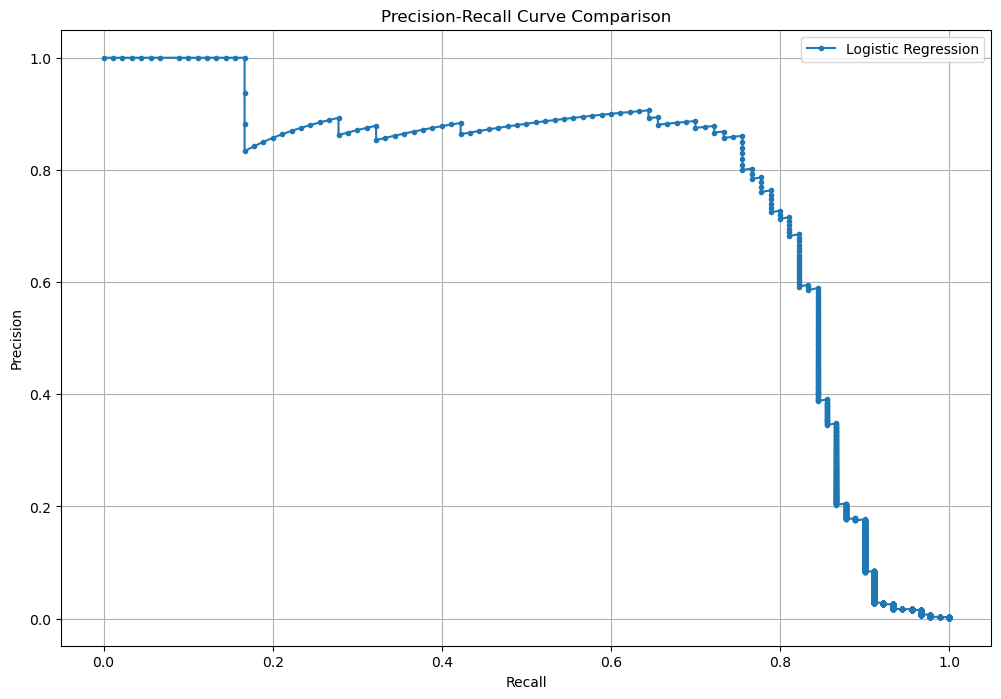

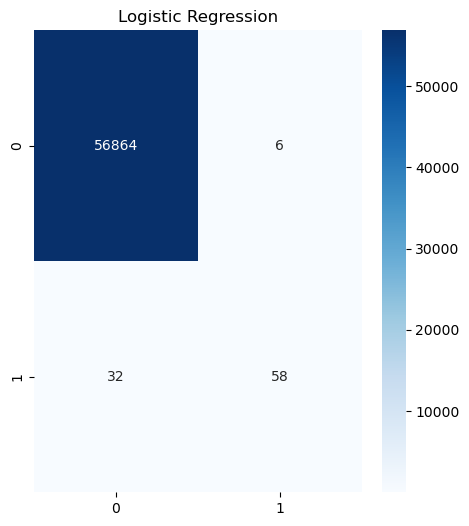

In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة البيانات الجديدة
test_data = pd.read_csv("data/trainval.csv")

# تقسيم البيانات إلى المدخلات والمخرجات
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

# دالة لتطبيق StandardScaler
def Scaling(data):
    st = StandardScaler()
    return st.fit_transform(data)

# تحميل النماذج
modelL = joblib.load('logistic_regression_model.pkl')

# Scaling البيانات
X_test_scaled = Scaling(X_test)

# تقييم النماذج
def evaluate_models(X_test, y_test, modelL):
    # التوقعات
    y_predict_logistic = modelL.predict(X_test)
    
    y_predictp_logistic = modelL.predict_proba(X_test)[:, 1]
    
    # طباعة نتائج النماذج
    print("Logistic Regression:")
    print("Accuracy =", accuracy_score(y_test, y_predict_logistic))
    print("Classification Report:\n", classification_report(y_test, y_predict_logistic))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_logistic))
    print("ROC AUC Score =", roc_auc_score(y_test, y_predictp_logistic))
    
    
    # مرئيات: رسم Precision-Recall Curve
    plt.figure(figsize=(12, 8))
    
    # Precision-Recall Curve لـ Logistic Regression
    precision_logistic, recall_logistic, _ = precision_recall_curve(y_test, y_predictp_logistic)
    plt.plot(recall_logistic, precision_logistic, marker='.', label='Logistic Regression')
    

    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # مرئيات: رسم Confusion Matrix
    plt.figure(figsize=(18, 6))
    
    # Confusion Matrix لـ Logistic Regression
    plt.subplot(1, 3, 1)
    sns.heatmap(confusion_matrix(y_test, y_predict_logistic), annot=True, fmt='d', cmap='Blues')
    plt.title('Logistic Regression')
    

    
    plt.show()

# استدعاء الدالة لتقييم النماذج
evaluate_models(X_test_scaled, y_test, modelL)
